# Vendor Oversight and Risk Monitoring Project

Goal: Build a system to monitor, rank, and explain vendor performance and compliance over time

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv('Vendor_Performance_Timeseries.csv')  # Load data into the DataFrame
df['report_month'] = pd.to_datetime(df['report_month'])

This block performs a basic performance evaluation for each vendor-month by calculating a risk score. It combines the unresolved account rate, dispute ratio, and compliance flags. The results are ranked to display the 20 highest-performance vendors, highlighting the best performance and compliance outliers.

In [4]:
# Unresolved Rate
df['unresolved_rate'] = 1 - df['recovery_rate']

# Dispute Ratio
df['high_dispute_ratio'] = df['dispute_count'] / df['total_accounts']

# Compliance Risk Flag
df['non_compliant'] = (
    (df['audit_score'] < 70) |
    (df['compliance_flags'] >= 2) |
    (df['license_expired'])
)

# Combined Risk Score (lower is better)
df['risk_score'] = (
    df['unresolved_rate'] +
    df['high_dispute_ratio'] +
    df['non_compliant'].astype(int)
)

# Show Top 20 Best Performers
top_performers = df.sort_values(by='risk_score', ascending=True).head(20)

print("\nTop 20 Best-Performing Vendors:")
print(top_performers[[
    'vendor_id', 'report_month', 'recovery_rate', 'audit_score',
    'compliance_flags', 'license_expired', 'unresolved_rate',
    'high_dispute_ratio', 'non_compliant', 'risk_score'
]].to_string(index=False))


Top 20 Best-Performing Vendors:
vendor_id report_month  recovery_rate  audit_score  compliance_flags  license_expired  unresolved_rate  high_dispute_ratio  non_compliant  risk_score
    V0012   2023-01-01          0.996         88.1                 1            False            0.004            0.002869          False    0.006869
    V0024   2023-06-01          0.984         79.5                 0            False            0.016            0.001001          False    0.017001
    V0009   2023-02-01          0.988         73.6                 0            False            0.012            0.006477          False    0.018477
    V0013   2023-01-01          0.991         75.1                 1            False            0.009            0.010741          False    0.019741
    V0017   2023-08-01          0.988         87.4                 0            False            0.012            0.013314          False    0.025314
    V0009   2023-10-01          0.973         76.3                 

Lets look at some trends. In this block I average recovery rates and audit and risk scores of all vendors (by month) to see if vendors are improving or falling off the wagon. This should help spot patterns and giver a clearer picture of where trends are heading.

In [5]:
# Group data by month and calculate average KPIs
monthly_avg = df.groupby('report_month').agg({
    'recovery_rate': 'mean',
    'audit_score': 'mean',
    'risk_score': 'mean',
    'non_compliant': 'mean'  # % of vendors flagged each month
}).reset_index()

# Rename columns for clarity
monthly_avg.columns = [
    'report_month',
    'avg_recovery_rate',
    'avg_audit_score',
    'avg_risk_score',
    'percent_non_compliant'
]

# Display monthly trends
print("\nMonthly Vendor Performance Summary:")
print(monthly_avg.to_string(index=False))


Monthly Vendor Performance Summary:
report_month  avg_recovery_rate  avg_audit_score  avg_risk_score  percent_non_compliant
  2023-01-01           0.563800        78.410000        1.047630               0.600000
  2023-02-01           0.638900        78.013333        0.838750               0.466667
  2023-03-01           0.529667        76.736667        0.984669               0.500000
  2023-04-01           0.583133        76.146667        0.895746               0.466667
  2023-05-01           0.597800        77.556667        0.812598               0.400000
  2023-06-01           0.632967        76.496667        0.911382               0.533333
  2023-07-01           0.567567        78.220000        0.882048               0.433333
  2023-08-01           0.539500        77.540000        0.972161               0.500000
  2023-09-01           0.600000        77.706667        0.880672               0.466667
  2023-10-01           0.526300        77.943333        0.984050               0.50

Recovery rates jumped around but dropped off in December. Audit scores dipped mid-year, then leveled out. Risk scores were mostly steady but ticked up again near the end. Around half the vendors were flagged every month, so compliance issues stayed pretty consistent throughout the year.

All that is great, but what we really want is to see who is doing well, who isn't, and who is on the edge CLEARLY. So, let's make some categories.

In [6]:
# Excellent vendor: solid performance, no compliance issues
df['excellent_vendor'] = (
    (df['recovery_rate'] > 0.6) &
    (df['non_compliant'] == False) &
    (df['risk_score'] < 0.8)
)

# At-risk vendor: high risk score or compliance problems
df['at_risk_vendor'] = (
    (df['risk_score'] > 1.0) |
    (df['non_compliant'] == True)
)

# Compliance risk only: audit/license issues but low unresolved/dispute rates
df['compliance_risk_only'] = (
    (df['non_compliant'] == True) &
    (df['unresolved_rate'] < 0.3) &
    (df['high_dispute_ratio'] < 0.05)
)

# Needs attention: not at-risk yet, but risk_score creeping toward threshold
df['needs_attention'] = (
    (df['risk_score'] > 0.85) &
    (df['risk_score'] <= 1.05) &
    (df['non_compliant'] == False)
)

# Review required: everyone else
df['review_required'] = (
    (~df['excellent_vendor']) &
    (~df['at_risk_vendor']) &
    (~df['needs_attention']) &
    (~df['compliance_risk_only'])
)

at_risk_vendors = df[df['at_risk_vendor'] == True]
most_at_risk = at_risk_vendors.sort_values(by='risk_score', ascending=False).head(20)

In [7]:
# Lets look at the counts for each vendor risk category
print("\nVendor Flag Counts:")
print("Excellent:", df['excellent_vendor'].sum())
print("Needs Attention:", df['needs_attention'].sum())
print("Compliance Risk Only:", df['compliance_risk_only'].sum())
print("Review Required:", df['review_required'].sum())
print("At Risk:", df['at_risk_vendor'].sum())


Vendor Flag Counts:
Excellent: 80
Needs Attention: 8
Compliance Risk Only: 60
Review Required: 93
At Risk: 179


In [8]:
# Lets look at the most at-risk vendor months
print("\nTop 20 Most At-Risk Vendor-Months:")
print(most_at_risk[[
    'vendor_id', 'report_month', 'risk_score', 'recovery_rate',
    'audit_score', 'compliance_flags', 'license_expired',
    'unresolved_rate', 'high_dispute_ratio'
]].to_string(index=False))


Top 20 Most At-Risk Vendor-Months:
vendor_id report_month  risk_score  recovery_rate  audit_score  compliance_flags  license_expired  unresolved_rate  high_dispute_ratio
    V0007   2023-04-01    1.938917          0.072         61.6                 3            False            0.928            0.010917
    V0010   2023-12-01    1.938669          0.067         85.8                 2            False            0.933            0.005669
    V0003   2023-09-01    1.925025          0.085         88.8                 1             True            0.915            0.010025
    V0001   2023-01-01    1.918000          0.087         92.1                 3            False            0.913            0.005000
    V0021   2023-01-01    1.917690          0.086         68.7                 2            False            0.914            0.003690
    V0001   2023-11-01    1.903711          0.103         86.3                 1             True            0.897            0.006711
    V0010   2023-08

In [9]:
# Group by vendor and sum flag occurrences across time
flag_summary = df.groupby('vendor_id')[[
    'excellent_vendor', 'needs_attention', 'compliance_risk_only',
    'review_required', 'at_risk_vendor'
]].sum().sort_values(by='at_risk_vendor', ascending=False)

print("\nVendor-Level Flag Summary (All Vendors):")
print(flag_summary.to_string())


Vendor-Level Flag Summary (All Vendors):
           excellent_vendor  needs_attention  compliance_risk_only  review_required  at_risk_vendor
vendor_id                                                                                          
V0005                     0                0                     2                0              12
V0014                     0                0                     4                0              12
V0019                     0                0                     3                0              12
V0021                     0                0                     4                0              12
V0025                     0                1                     4                1              10
V0028                     0                0                     5                2              10
V0007                     1                0                     1                2               9
V0029                     1                0              

Yeesh, these vendors don't seem all that effective... Nevermind needs review,  there's more than twice as many at-risk vendors as there are excellent and about 70% more that require deeper review! Thankfully its a simulated dataset!

This pulls together the worst vendor-months so I can see exactly who’s messing up and why. It shows recovery, audit, flags, and a quick explanation of what’s going wrong—low recovery, expired license, whatever it is. Makes it easy to spot who needs a conversation or a contract check.

In [10]:
def explain_vendor(row):
    reasons = []
    if row['recovery_rate'] < 0.5:
        reasons.append("Low recovery rate")
    if row['audit_score'] < 70:
        reasons.append("Low audit score")
    if row['compliance_flags'] >= 2:
        reasons.append("Multiple compliance flags")
    if row['license_expired']:
        reasons.append("License expired")
    if row['high_dispute_ratio'] > 0.05:
        reasons.append("High dispute ratio")
    return "; ".join(reasons) if reasons else "No major concerns"

df['explanation'] = df.apply(explain_vendor, axis=1)

In [11]:
# Count how many times each vendor was flagged as at-risk over the year
long_term_risk = df[df['at_risk_vendor'] == True].groupby('vendor_id').size().reset_index(name='at_risk_count')

# Sort vendors with the most at-risk months at the top
long_term_risk = long_term_risk.sort_values(by='at_risk_count', ascending=False)

# Show results
print("\nVendors with the Most At-Risk Months:")
print(long_term_risk.to_string(index=False))


Vendors with the Most At-Risk Months:
vendor_id  at_risk_count
    V0005             12
    V0014             12
    V0019             12
    V0021             12
    V0025             10
    V0028             10
    V0007              9
    V0029              9
    V0002              8
    V0013              8
    V0001              7
    V0003              6
    V0015              6
    V0008              5
    V0027              5
    V0009              5
    V0022              5
    V0024              4
    V0004              4
    V0030              4
    V0017              4
    V0011              4
    V0023              3
    V0012              3
    V0010              3
    V0026              3
    V0020              2
    V0018              2
    V0006              1
    V0016              1


In [12]:
# Filter only at-risk vendors
investigation_table = df[df['at_risk_vendor'] == True].sort_values(by='risk_score', ascending=False)

# Select key columns for investigation
investigation_table = investigation_table[[
    'vendor_id', 'report_month', 'risk_score', 'recovery_rate',
    'audit_score', 'compliance_flags', 'license_expired',
    'high_dispute_ratio', 'explanation'
]]

print("\nInvestigation Table – Most At-Risk Vendor-Months:")
print(investigation_table.to_string(index=False))


Investigation Table – Most At-Risk Vendor-Months:
vendor_id report_month  risk_score  recovery_rate  audit_score  compliance_flags  license_expired  high_dispute_ratio                                                                    explanation
    V0007   2023-04-01    1.938917          0.072         61.6                 3            False            0.010917                  Low recovery rate; Low audit score; Multiple compliance flags
    V0010   2023-12-01    1.938669          0.067         85.8                 2            False            0.005669                                   Low recovery rate; Multiple compliance flags
    V0003   2023-09-01    1.925025          0.085         88.8                 1             True            0.010025                                             Low recovery rate; License expired
    V0001   2023-01-01    1.918000          0.087         92.1                 3            False            0.005000                                   Low recov

In [13]:
# Filter only at-risk rows
at_risk_df = df[df['at_risk_vendor'] == True].copy()

# Group by vendor and summarize their risk profile
vendor_summary = at_risk_df.groupby('vendor_id').agg({
    'risk_score': 'mean',
    'recovery_rate': 'mean',
    'audit_score': 'mean',
    'compliance_flags': 'sum',
    'license_expired': 'sum',
    'high_dispute_ratio': 'mean',
    'explanation': lambda x: "; ".join(set(e for e in x if e != "No major concerns"))
}).reset_index()

# Count how many times each vendor was flagged
vendor_summary['at_risk_count'] = at_risk_df.groupby('vendor_id').size().values

# Sort vendors by how many times they were at risk, then by average score
vendor_summary = vendor_summary.sort_values(
    by=['at_risk_count', 'risk_score'], ascending=[False, False]
)

# Truncate explanation text to prevent row wrapping
vendor_summary['explanation'] = vendor_summary['explanation'].str.slice(0, 70)

# Display clean, single-row layout
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 200)
print(vendor_summary[[
    'vendor_id', 'at_risk_count', 'risk_score', 'recovery_rate',
    'audit_score', 'compliance_flags', 'license_expired',
    'high_dispute_ratio', 'explanation'
]].to_string(index=False))

vendor_id  at_risk_count  risk_score  recovery_rate  audit_score  compliance_flags  license_expired  high_dispute_ratio                                                            explanation
    V0005             12    1.568976       0.442750    60.183333                 2                3            0.011726 Low recovery rate; Low audit score; License expired; Low audit score; 
    V0019             12    1.542843       0.469833    58.708333                10                3            0.012676 Low audit score; License expired; Low recovery rate; Low audit score; 
    V0021             12    1.417976       0.595583    63.925000                 7                1            0.013559 Low audit score; License expired; Multiple compliance flags; Low recov
    V0014             12    1.353171       0.661917    63.241667                16                0            0.015088 Low recovery rate; Low audit score; Low recovery rate; Low audit score
    V0025             10    1.414169       0.

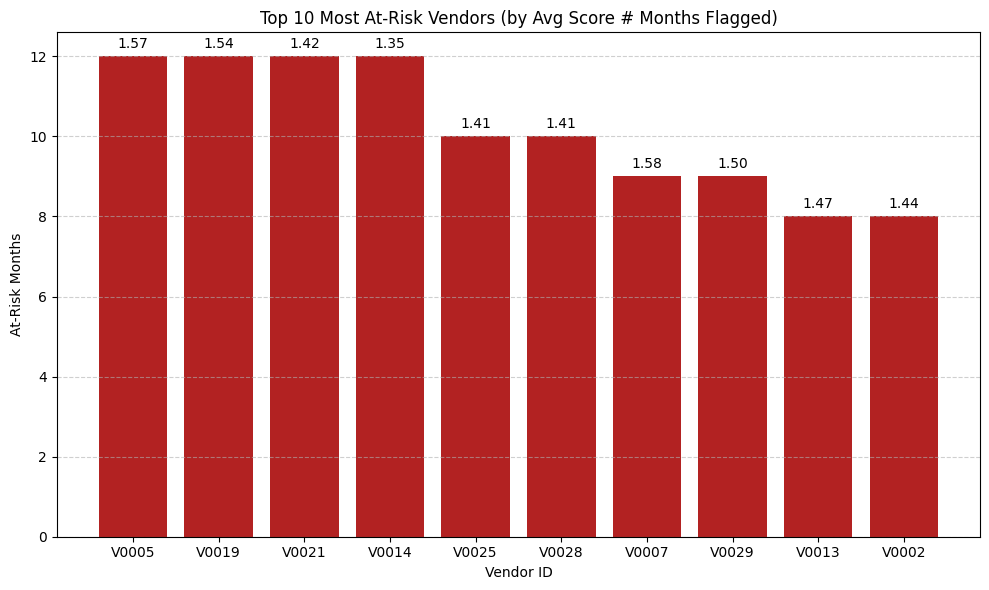

In [16]:
# Top 10 most at-risk vendors by count
top_vendors = vendor_summary.sort_values(by='at_risk_count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_vendors['vendor_id'], top_vendors['at_risk_count'], color='firebrick')

# Add average risk score labels on each bar
for bar, score in zip(bars, top_vendors['risk_score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{score:.2f}",
             ha='center', fontsize=10)

plt.title("Top 10 Most At-Risk Vendors (by Avg Score # Months Flagged)")
plt.xlabel("Vendor ID")
plt.ylabel("At-Risk Months")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Now, lets check the trends. I bet the best way to do that is to simply find the change in time (delta) for each vendor.

In [18]:
# Group by report_month and get average metrics
monthly_trends = df.groupby('report_month').agg(
    avg_recovery_rate=('recovery_rate', 'mean'),
    avg_audit_score=('audit_score', 'mean'),
    avg_risk_score=('risk_score', 'mean'),
    percent_non_compliant=('non_compliant', 'mean')
).reset_index()

# Preview all months
print("\nMonthly Averages (All Months):")
print(monthly_trends.to_string(index=False))

# Get the first and last months
first = monthly_trends.iloc[0]
last = monthly_trends.iloc[-1]

# Calculate overall change
trend_summary = {
    'Recovery Rate Change': last['avg_recovery_rate'] - first['avg_recovery_rate'],
    'Audit Score Change': last['avg_audit_score'] - first['avg_audit_score'],
    'Risk Score Change': last['avg_risk_score'] - first['avg_risk_score'],
    'Non-Compliant % Change': last['percent_non_compliant'] - first['percent_non_compliant']
}

# Print changes
print("\nOverall Change from First to Last Month:")
for metric, change in trend_summary.items():
    print(f"{metric}: {change:+.3f}")


Monthly Averages (All Months):
report_month  avg_recovery_rate  avg_audit_score  avg_risk_score  percent_non_compliant
  2023-01-01           0.563800        78.410000        1.047630               0.600000
  2023-02-01           0.638900        78.013333        0.838750               0.466667
  2023-03-01           0.529667        76.736667        0.984669               0.500000
  2023-04-01           0.583133        76.146667        0.895746               0.466667
  2023-05-01           0.597800        77.556667        0.812598               0.400000
  2023-06-01           0.632967        76.496667        0.911382               0.533333
  2023-07-01           0.567567        78.220000        0.882048               0.433333
  2023-08-01           0.539500        77.540000        0.972161               0.500000
  2023-09-01           0.600000        77.706667        0.880672               0.466667
  2023-10-01           0.526300        77.943333        0.984050               0.500000


Although vendors are recovering a little less, they have improved significantly in quality, risk management, and rule compliance over the period analyzed.

LEts look at the 5 months with the highest risk scores

In [20]:
# Show top 5 months with highest risk score
print("\nTop 5 Risk Score Spike Months:")
print(monthly_trends.sort_values(by='avg_risk_score', ascending=False).head(5)[['report_month', 'avg_risk_score']])

# Show top 5 months with highest % non-compliance
print("\nTop 5 Compliance Risk Months:")
print(monthly_trends.sort_values(by='percent_non_compliant', ascending=False).head(5)[['report_month', 'percent_non_compliant']])


Top 5 Risk Score Spike Months:
   report_month  avg_risk_score
10   2023-11-01        1.070124
0    2023-01-01        1.047630
11   2023-12-01        1.013995
2    2023-03-01        0.984669
9    2023-10-01        0.984050

Top 5 Compliance Risk Months:
   report_month  percent_non_compliant
0    2023-01-01               0.600000
10   2023-11-01               0.600000
5    2023-06-01               0.533333
2    2023-03-01               0.500000
11   2023-12-01               0.500000


The highest risk months are concentrated at the tails of the year. This might indicate holiday-based seasonality. Additionally, there's June's high compliance risk, too, which might indicate bi-annual seasonality (like licenses expriring) since June is the end of Q2

This section tracks how vendor performance and compliance changed over the year. Recovery rates dipped late in the year, while risk scores climbed in Q4. A few months saw major spikes, especially 11-2023. Overall, performance slipped and compliance stayed shaky.

# Conclusions and Recommendations

**What I Saw:**
- Performance dropped in the tails of the year, especially in December, where-->
- Recovery rates declined while risk scores and compliance issues climbed.
- Audit scores dipped mid-year but for the most part stayed consistent.
- Roughly half the vendors were flagged for compliance issues every month.

**What Stood Out:**
- Vendors like V0001 were flagged multiple times with consistent issues.
- Q4 was the weakest quarter in terms of risk and compliance.
- Very few vendors ever met the “excellent” criteria—most hovered at average or below. That is to be expected, most data points are centered at the mean, but when there is an objectively defined set of criteria that designates "success", average becomes less than average.

**What I’d Recommend:**
- Review the top 5 most at-risk vendors for potential retraining or replacement.
- Set up alerts when a vendor is flagged 2+ times within 6 months.
- Raise the bar for compliance—expired licenses and repeated flags should be disqualifying.
- Build a monthly-updating weighted vendor health score (probably by combining recovery rate, audit score, compliance flags, etc.) to proactively manage risk moving forward.